<a href="https://colab.research.google.com/github/de-Medeiros-insect-lab/2026_UIUC_workshop_llm_pdf_extraction/blob/manual_changes/workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extracting structured data from PDFs with open models

In this workshop, we will learn how to interact programmatically with large language models (LLMs) and then apply this to the task of extracting structured data from PDFs.

Everything here runs free on Google Colab using a GPU with 16GB of RAM, which is enough for low-end LLMs. If you have this memory on your machine, you can run locally too by downloading this as a python notebook. You can run python notebooks using [Jupyter](https://jupyter.org/), among other software.

We will go through 5 steps:

1. **Setup** — talking to a language model from Python
2. **Preparing documents** — OCR and figure extraction
3. **Structured extraction** — getting tables out of unstructured text
4. **An agent** — creating an AI agent that chooses the best approach
5. **Scaling up** — a bigger model in the cloud, and a whole folder of PDFs



**To get started, set your runtime to a GPU before you start:** Runtime → Change runtime type → T4.
Then click *Connect*

---
# Session 1 — Setup, and talking to a model

## 1.1 - Interacting with Ollama through the desktop app

We asked you to install the [Ollama Desktop app](https://ollama.com/) before the workshop. Let's first interact with it locally on your computer, and later we will do the same programmatically through this python notebook.

Ollama is one of the programs that you can use to deploy large language models with open weights. These are [open-source models](https://en.wikipedia.org/wiki/Open-source_artificial_intelligence) that you can run for free on your own device, or rent cloud computing to run. These include the models trained by Chinese companies and highly talked about in the media, but some US-based companies also release open source models (OpenAI has [a few, now a bit outdated](https://ollama.com/library/gpt-oss), and meta [just released a new one](https://ollama.com/library/muse-glimmer)).

You do not need Ollama to run open models, but Ollama offers a convenient engine that automatically figures out the best way to deploy a model on your hardware. For pure python, you can check the [Transformers library and models hosted by Huggingface](https://huggingface.co/docs/transformers/en/index). We will have Ollama running as a server in the background in this workshop and use python to communicate with this server. As you learn more about using LLMs, you can explore the Transformers library, [vLLM](https://vllm.ai/), [unsloth](https://unsloth.ai/) and other ways to do this.

Let's start opening Ollama on your own computer. Click on *New chat*, choose the model *deepseek-r1:1.5b*, and start chatting. The interface should be familiar to you, similar to other web-based chatbots.
* We are using *deepseek-r1:1.5b* because it is a very small model that can run on pretty much any of your computers, whether or not you have a powerful GPU. Let's start with this one so everyone is on the same page.
* **DO NOT USE A CLOUD MODEL YET**

## 1.2 - Interacting with Ollama through the command line

Now that you are comfortable with the graphical user interface, let's chat with Ollama through a command line, which is one level closer to what we will do here. While Ollama is open, open a terminal (for Windows, Windows PowerShell; for Macs, Terminal; for Ubuntu, GNOME Shell, etc).

Type the following command:
```{bash}
curl http://localhost:11434/v1/chat/completions -H "Content-Type: application/json" -d '{ "model": "deepseek-r1:1.5b", "messages": [ { "role": "user", "content": "Which insect is the best? One must choose one and one only" } ] }'
```

### What you will see back

You will get a very long line in [JSON format](https://en.wikipedia.org/wiki/JSON). Here I am showing results that I got when preparing the workshop, broken over several lines, with some parts numbered for us to discuss them:

```json
{
  "id": "chatcmpl-364",
  "object": "chat.completion",
  "created": 1786808743,
  "model": "deepseek-r1:1.5b",                 // 1️⃣
  "choices": [
    {
      "index": 0,
      "message": {
        "role": "assistant",                   // 2️⃣
        "content": "Ants are the best ...",    // 3️⃣
        "reasoning": "Alright, so I need ..."  // 4️⃣
      },
      "finish_reason": "stop"                  // 5️⃣
    }
  ],
  "usage": { "prompt_tokens": 16, "completion_tokens": 638, "total_tokens": 654 }   // 6️⃣
}
```

(The `//` lines are our annotations — real JSON has no comments.)

| | field | what it is |
| :-- | :-- | :-- |
| 1️⃣ | `model` | the name of the model used. |
| 2️⃣ | `role` | `assistant`, `user` or `system`; in this case, a response, so `assistant`. |
| 3️⃣ | `content` | **the answer**. The only part a chat window shows you. |
| 4️⃣ | `reasoning` | the model thinking out loud first, kept separate. Only reasoning models return this. |
| 5️⃣ | `finish_reason` | `stop` means it finished. `length` means it hit a limit mid-sentence and your answer is cut off. Always check this. |
| 6️⃣ | `usage` | Number of tokens used, important for cost and model context. |

### 3️⃣ &nbsp;The answer

> Ants are the best because they excel in pollination, carrying and spreading
> pollens throughout most of their lifetime in their home regions. This makes
> them highly effective in ensuring plant reproduction.

### 4️⃣ &nbsp;The reasoning

> Alright, so I need to figure out which insect is the best. I guess the user is asking for the most effective or the best known insect. Let me start by thinking about insects in general—there are over 30, each with different roles and uses, from ants to moles.
>
> I remember that ants are generally noted for their work in pollination. They carry fruit all year around and are crucial for pollination in their native regions. Moles, on the other hand, I think are good at defense and scaring off neighbors, which probably helps them survive. They can be aggressive and make aggressive behavior.
>
> Wait, but if I'm comparing ants and moles, which one is better in what ways? The user said to choose one only, but that's confusing because they're two different insects with distinct roles. Maybe the user is asking which kind is the best or perhaps comparing based on specific aspects.
>
> Let me think about size. Moles are generally smaller than ants, so ants are larger. But ants are more effective in certain ways. Maybe I should consider their reproductive success in pollination, which ants do more than moles. Also, ants might be more aggressive, so if the user values that, perhaps ants are better.
>
> Another angle is their behavior. Moles are known for being aggressive, which can be advantageous in some environments. However, they might not handle certain tasks as efficiently as ants. On the flip side, if the focus is on defense, moles might be better, but their reputation as scaring off neighbors is something ants don't have.
>
> I'm a bit torn because there's no universal "best." The answer will depend on the criteria. If it's based on ability to pollinate, ants are better. If it's based on defense, moles might be better. But since the user is asking for an insect, not a group, perhaps they want a single answer. Maybe the ants are superior at pollination.
>
> Alternatively, maybe the question is about the best insect for garden use, considering factors like defense, size, and functionality. In that case, moles could be better for defense but less effective in pollination. But if considering a mix, like defense and pollination, maybe it's a balance.
>
> I'm also thinking about the user's perspective. They might be looking for an insect that's efficient in their specific niche, like for pollination, or maybe in defense. Without knowing exactly, it's a bit unclear. But I'll conclude that while there might not be a single best insect, between the two, considering pollination, ants are superior. So I'll say ants are the best because they excel in pollination and are effective.
>
> Wait, but the user might be looking for something else, like functional traits or specific environmental roles. So perhaps the answer could vary based on the criteria. But sticking with pollination seems solid, so ants are my choice for that.

## Three things to take from this response:

- A chat window shows you the response 3️⃣ only. Working
  programmatically you get a lot more information, including all reasoning and lots of metadata.
- Reasoning is necessary for some tasks, but it is expensive.
- Reasoning has limits: small models may still hallucinate.

## 1.3 - Interacting with Ollama through a cloud Python notebook

From now on, we will still be running Ollama, but not on your own computer. This colab notebook runs on a cloud instance on a Google server. The free tier is limited to GPUs with 16 GB of memory (so this is the maximum model size + data we can use). We will install Ollama on the server, download models and interact with them.

**What we're doing:** installing Ollama, downloading a language model, and
sending it our first messages from Python.

**Why:** everything later in the day is this same call with more structure
around it. We will get comfortable with it now, while the parts are still small.

In [32]:
# Colab setup. Takes ~2 minutes on a fresh machine.
import os, subprocess, sys

IN_COLAB = "google.colab" in sys.modules
REPO = "2026_UIUC_workshop_llm_pdf_extraction"

if IN_COLAB:
    # zstd unpacks Ollama's installer; pciutils lets it find the GPU.
    !DEBIAN_FRONTEND=noninteractive apt-get -qq install -y zstd pciutils > /dev/null
    !curl -fsSL https://ollama.com/install.sh | sh
    !pip -q install ollama pymupdf pandas pillow
    if os.path.basename(os.getcwd()) != REPO:   # so this cell is safe to re-run
        if not os.path.isdir(REPO):
            !git clone -q https://github.com/de-Medeiros-insect-lab/{REPO}.git
        os.chdir(REPO)
    subprocess.Popen(["ollama", "serve"],
                     stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

import time, base64, json, glob, re
import ollama, pymupdf, pandas as pd
from PIL import Image
from IPython.display import display, Image as ShowImage
import io

>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> NVIDIA GPU installed.
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


The code below just checks whether the server is ready so we do not get an error when using it.

In [33]:
def server_ready(timeout=120):
    """Wait until Ollama answers, or give up."""
    deadline = time.time() + timeout
    while time.time() < deadline:
        try:
            ollama.list()
            return True
        except Exception:
            time.sleep(1)
    return False

assert server_ready(), "Ollama did not start"
print("Ollama is up")

Ollama is up


### Check you actually have a GPU

Models can run on a CPU, but then they get very slow. So let's check whether you have a GPU.

In [34]:
def gpu_report():
    try:
        smi = subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total",
                              "--format=csv,noheader"],
                             capture_output=True, text=True)
        print("GPU:", smi.stdout.strip() if smi.returncode == 0 else "none")
    except FileNotFoundError:
        print("GPU: none")
    try:
        ps = subprocess.run(["ollama", "ps"], capture_output=True, text=True)
        rows = [r for r in ps.stdout.strip().splitlines()[1:] if r.strip()]
        print("Ollama is running:", rows or "nothing loaded yet")
    except FileNotFoundError:
        print("Ollama is running: the ollama command was not found -- "
              "did the setup cell above finish?")

gpu_report()

GPU: Tesla T4, 15360 MiB
Ollama is running: nothing loaded yet


If you do not have a GPU, **STOP** and ask the instructors. You may have forgotten to choose the T4 runtime type.

Now we will download our chat model. For convenience, we will save our chat model value in a variable so we can reuse it. We will use the model [Qwen 3.5](https://qwen.ai/blog?id=qwen3.5) with 9 billion parameters, which takes ~6.5 GB of RAM. It is a quite powerful model for a small size, with capabilities of chatting, reasoning, using tools, and taking images as input. More powerful versions of Qwen have more parameters, but need more RAM.

The terminal command to ask ollama to download a model is `ollama pull`. In a python
notebook we can run a terminal command by starting the line with `!`, and paste the
value of a python variable into it with `{}` — so `!ollama pull {CHAT_MODEL}` runs
`ollama pull qwen3.5:9b`. The download is ~6.5 GB, so start it and keep reading.

In [35]:
CHAT_MODEL = "qwen3.5:9b"
!ollama pull {CHAT_MODEL}

### Your first message

A conversation is a list of messages. Each has a `role` and `content`.
`temperature` sets how noisy a model will be. Higher temperature may make responses more creative because they are more variable. In our context, we typically want `temperature=0`, which makes the model as predictable and repeatable as it can be.

In [36]:
reply = ollama.chat(
    model=CHAT_MODEL,
    messages=[{"role": "user", "content": "What is a rostrum on a beetle?"}],
    think=False,
    options={"temperature": 0},
)
print(reply.message.content)

In beetles (order Coleoptera), the **rostrum** (also commonly called the **pronotum extension**, **snout**, or **clypeus-labrum complex** depending on specific anatomy) is a distinct, often elongated projection that extends forward from the head.

Here is a detailed breakdown of its structure and function:

### 1. Anatomical Structure
The rostrum is not a separate body part but rather an extension of the **head capsule**. It typically consists of three main parts fused together:
*   **Clypeus**: The plate located just above the mouthparts (mandibles).
*   **Labrum**: The upper lip.
*   **Mental Suture**: The area where these structures meet and extend forward.

In many beetle families, this structure is highly modified. It can be very short and barely visible (as in *Carabidae* or ground beetles) or extremely long and prominent (as in *Curculionidae*, the weevils). In weevils, for example, the rostrum often houses the antennae within grooves along its length.

### 2. Primary Functions


### The system prompt

A `system` message sets who the model is being. Language models are best
understood as role-playing machines:

> Shanahan, M., McDonell, K. & Reynolds, L. Role play with large language
> models. *Nature* **623**, 493–498 (2023).

Say clearly what role you want, and the model will follow. They know lots of roles from the training data!

Let's try sending a message with a strict system constraint.

Note that we are using `think=False`: the model will just answer directly without reasoning first.

In [37]:
reply = ollama.chat(
    model=CHAT_MODEL,
    messages=[
        {"role": "system",
         "content": "You are an expert coleopterist. Answer in two sentences."},
        {"role": "user",
         "content": "What is a rostrum, and which beetles have one?"},
    ],
    think=False,
    options={"temperature": 0},
)
print(reply.message.content)

A rostrum is the elongated, beak-like projection extending forward from the head of certain beetles, formed by the fusion of the clypeus and labrum. This structure is most famously found in weevils (Curculionoidea) but also occurs in various other families such as longhorned beetles (Cerambycidae), leaf beetles (Chrysomelidae), and fireflies (Lampyridae).


**Check that answer against what you know.**

A 9B model is fluent about many things but not very reliable — it may well
have just told you something confidently wrong.

This is why we will extract text *from documents* rather than
asking the model what it knows. Both using larger models and providing stronger contextualization will decrease the chances that the model will make stuff up.

### Hands-on 1

Change the role and the question. Try an empty system prompt, then a very
detailed one, and compare.

In [38]:
reply = ollama.chat(
    model=CHAT_MODEL,
    messages=[
        {"role": "system", "content": "WRITE A ROLE HERE"},
        {"role": "user",   "content": "ASK YOUR QUESTION HERE"},
    ],
    think=False,
    options={"temperature": 0},
)
print(reply.message.content)

I am ready to help! Since you haven't asked a specific question yet, here are a few ways we can proceed:

1.  **Ask me anything:** You can ask about facts, history, science, coding, writing, or general knowledge.
2.  **Solve a problem:** Paste a math equation, a logic puzzle, or a coding error you're facing.
3.  **Creative Writing:** Give me a prompt, and I can write a story, poem, or script.
4.  **Roleplay:** Tell me who you want me to be (e.g., "Act as a strict history teacher" or "Be my travel agent"), and we can start that scenario.

**What would you like to do first?**


### Thinking

This model can reason before answering. `think=True` returns that reasoning
separately from the answer. Let's try the same question as above:

In [39]:
reply = ollama.chat(
    model=CHAT_MODEL,
    messages=[
        {"role": "system",
         "content": "You are an expert coleopterist. Answer in two sentences."},
        {"role": "user",
         "content": "What is a rostrum, and which beetles have one?"},
    ],
    think=True,
    options={"temperature": 0},
)

print("--- reasoning ---\n", reply.message.thinking)
print("--- answer ---\n", reply.message.content)

--- reasoning ---
 Thinking Process:

1.  **Analyze the Request:**
    *   Role: Expert coleopterist (beetle specialist).
    *   Task: Define "rostrum" and identify which beetles have one.
    *   Constraint: Answer in exactly two sentences.

2.  **Define "Rostrum":**
    *   In entomology, specifically coleoptera, a rostrum is an elongated projection of the head or pronotum that separates the eyes from the clypeus/mouthparts. It's often associated with the labrum and mandibles being tucked underneath.
    *   More precisely: It's a beak-like structure formed by the extension of the head capsule (clypeus, frons, etc.) in certain beetle families.

3.  **Identify Beetles with Rostrum:**
    *   Curculionidae (Weevils) - definitely have a rostrum.
    *   Brentidae (some).
    *   Rhynchitidae (often merged into Curculionidae now).
    *   Some longhorn beetles (Cerambycidae) have a "rostrum" but it's often just the head extension, sometimes called a rostrum in older texts, but strictly 

Reasoning is not always a win. On a task with nothing to reason about — copying
text out of an image, say — it can ramble for pages and never answer. We use
`think=False` for that. For more complicated tasks, it may help tremendously.

**Recap.** You installed Ollama, pulled a model, and sent it messages. You set
a role with a system prompt, evaluated the model responses, and switched its reasoning on and off. Next: getting text out of
real documents.

---
# Session 2 — Preparing documents

**What we're doing:** turning two PDFs into text and images we can feed to a
model — one born-digital, one a 1929 scan.

**Why:** a PDF is not a text file. What you can get out of it, and how much you
can trust it, depends entirely on how it was made.

Very powerful models (e.g. Claude models) can read PDFs natively, but use a lot of tokens for it. If we prepare our PDFs beforehand as text and images, we can get high-quality responses with a much lower cost.

It is very common for old scans to have used outdated OCR tools, so it is usually a good idea to re-run OCR. Here we will use Ollama to do OCR using a modern model.

OCR models are highly specialized - they only do OCR and nothing else. So they are usually pretty good even being small. And models from Chinese companies tend to be very good in multiple languages. Here we will use [deepseek OCR](https://github.com/deepseek-ai/DeepSeek-OCR) as our OCR model. It is not the latest version, but it is already excellent and supported by Ollama.

In [40]:
# ~6.7 GB. Start it now, it downloads while we talk.
OCR_MODEL  = "deepseek-ocr"    # transcribes page images
!ollama pull {OCR_MODEL}

We will now define several small functions that we will call constantly throughout the day. We will not explain in detail how each one works, only their general goal. Feel free to use these functions in your own code, and get your favorite chatbot to explain them to you if you are curious!

**open_pdf()**: opens a pdf file using the [pymupdf library](https://pymupdf.readthedocs.io/en/latest/)

**get_page_text()**: gets a specific page from a loaded pdf.

**render_page()**: encodes a pdf page in the format required by an LLM

**DEFAULT_DPI**: the resolution we will be using. We are limiting to 100 dpi here so we limit the memory (and number of tokens, and computing time, etc). Probably sufficient for most text and figures.

The two PDFs we will use are taxonomic publications, one born-digital and the other historical and digitized. You can find them in the [github repository](https://github.com/de-Medeiros-insect-lab/2026_UIUC_workshop_llm_pdf_extraction)

In [41]:
DEFAULT_DPI = 100   # enough to read fine print; higher is slower for little gain

def open_pdf(path):
    return pymupdf.open(path)

def get_page_text(doc, page):
    """The text layer already stored inside the PDF. Free and instant."""
    if not 1 <= page <= doc.page_count:
        raise ValueError(f"page {page} out of range (1-{doc.page_count})")
    return doc[page - 1].get_text()

def render_page(doc, page, dpi=DEFAULT_DPI):
    """Draw a page as an image, encoded for sending to a model."""
    if not 1 <= page <= doc.page_count:
        raise ValueError(f"page {page} out of range (1-{doc.page_count})")
    return base64.b64encode(
        doc[page - 1].get_pixmap(dpi=dpi).tobytes("png")).decode()

modern = open_pdf("example_pdfs/deMedeiros2013Zootaxa.pdf")   # 2013, born-digital
legacy = open_pdf("example_pdfs/Marshall1929_AnnMagNatHist.pdf")  # 1929, scanned
print(modern.page_count, "pages |", legacy.page_count, "pages")

7 pages | 8 pages


### Two documents, two kinds of text

In [42]:
print("MODERN, page 2:")
print(repr(get_page_text(modern, 2)[:180]))
print()
print("LEGACY, page 5:")
print(repr(get_page_text(legacy, 5)[:180]))

MODERN, page 2:
' Zootaxa 3636 (2)  © 2013 Magnolia Press  ·  395\nTHREE NEW ANCHYLORHYNCHUS FROM COLOMBIA\nMaterial and methods\nAll specimens examined were collected by L. A. Núñez-Avellaneda, and d'

LEGACY, page 5:
'new South American Cureulionidse. \n267 \nLegs approximately equal in length; femora slender, suh- \nlinear and not toothed, the hind pair not exceeding the apex \nof the elytra; tibia'


The legacy text is not empty. It is not obviously broken either. Look closely:
the family name reads `Cureulionidse`. The scanner's OCR ran years ago and got
it wrong, and nothing in the file makes this clear.

That is a dangerous and common case. Better never trust the OCR that comes with a historical PDF.

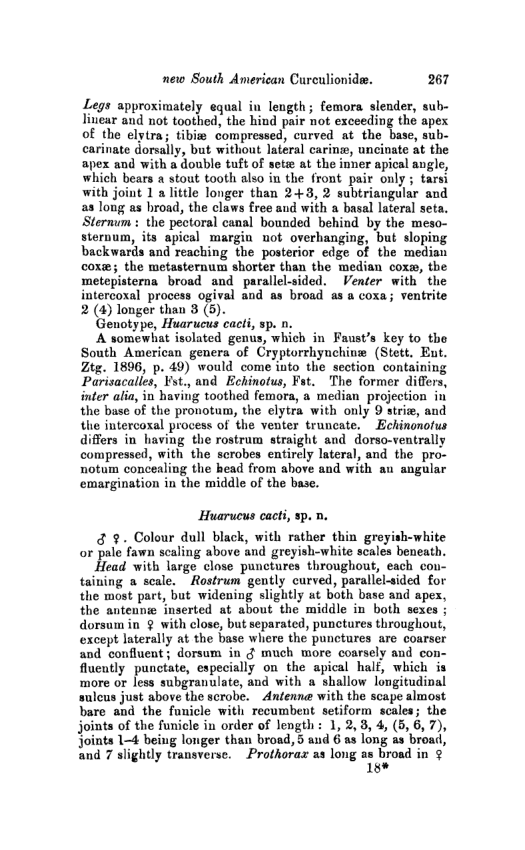

In [43]:
from IPython.display import Image as ShowImage, display
display(ShowImage(data=base64.b64decode(render_page(legacy, 5))))

### Figures: two completely different jobs

In a born-digital PDF, figures are **objects**. You pull them out exactly using code. Here we use functions from the pymupdf library:

page 1: 1 embedded image(s)
page 3: 1 embedded image(s)
page 4: 1 embedded image(s)
page 5: 2 embedded image(s)
saved figure_zootaxa.png 1339 x 1505


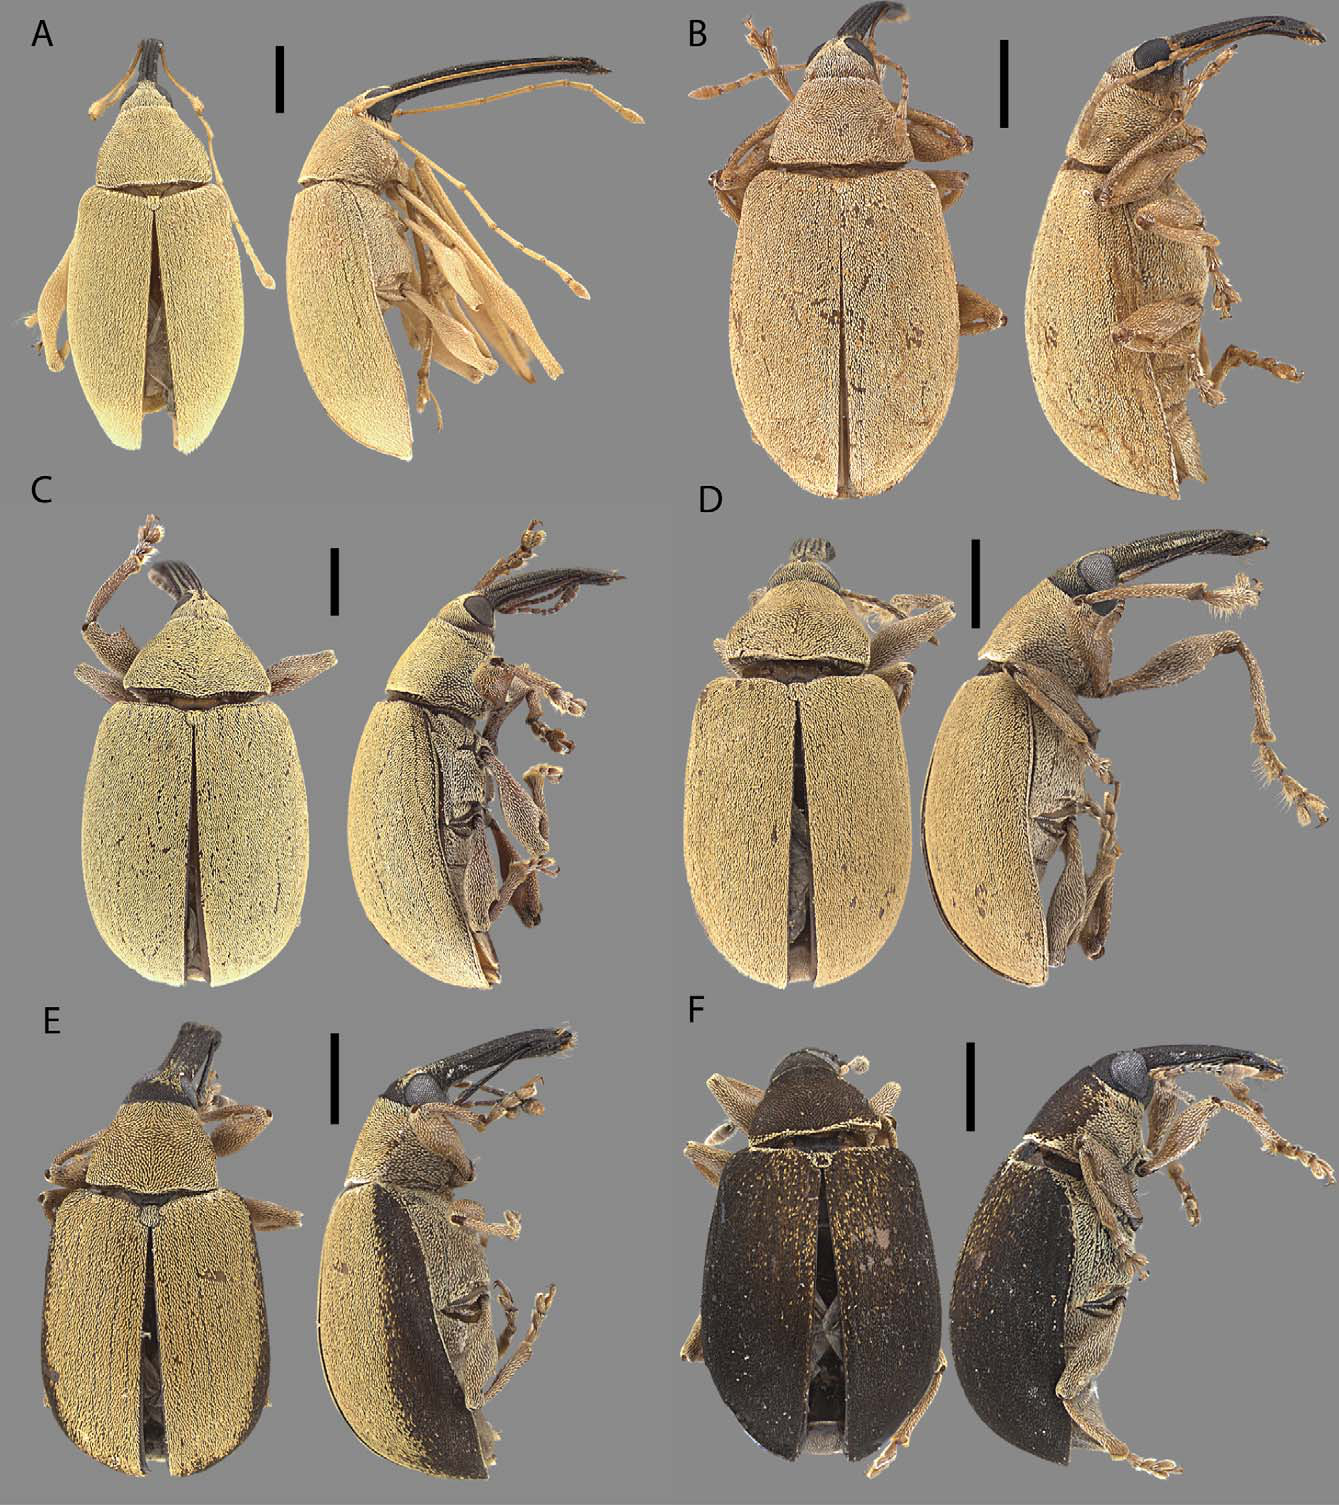

In [44]:
for pno in range(1, modern.page_count + 1):
    imgs = modern[pno - 1].get_images(full=True)
    if imgs:
        print(f"page {pno}: {len(imgs)} embedded image(s)")

xref = modern[2].get_images(full=True)[0][0]
pix = pymupdf.Pixmap(modern, xref)
pix.save("figure_zootaxa.png")
print("saved figure_zootaxa.png", pix.width, "x", pix.height)
display(ShowImage(filename="figure_zootaxa.png", width=380))

In a scan there are no objects — the whole page is one photograph. Page 6 of
the 1929 paper has a drawing of *Huarucus cacti* on it, but there is nothing
to extract. We have to **find** it.

In [45]:
print("objects on legacy page 6:",
      len(legacy[5].get_images(full=True)), "-- the page scan itself")

objects on legacy page 6: 1 -- the page scan itself


### OCR with layout

`deepseek-ocr` transcribes a page image, and asked the right way it also
reports *where* things are.

When using the ollama library, we need `ollama.generate`, not
`ollama.chat` to get the layout in addition to the text.

Because OCR models are very specialized, they need a very specific prompt. In the case of deepseek OCR, this is documented in their github page. To get the text from a page and its layout, we need the following prompt: `"<image>\n<|grounding|>Convert the document to markdown."`

Let's do that for one page of the historical PDF:

In [46]:
reply = ollama.generate(
        model=OCR_MODEL,
        prompt="<image>\n<|grounding|>Convert the document to markdown.",
        images=[render_page(legacy, 6, dpi=100)],
        options={"temperature": 0, "num_predict": 4096},
    )
print(reply.response)

text[[152, 114, 855, 239]]
and usually slightly transverse in \(\mathcal{S}\) , strongly rounded at the sides, widest well behind the middle, narrowing to the base and more so anteriorly, with a shallow subapical constriction; the basal margin truncate and twice as wide as the apex, which is gently arcuate dorsally, the postocular lobes with a dense fringe of short setae; the dorsum gently convex longitudinally and highest in front of the middle, densely set  

image[[287, 258, 718, 715]]
image_caption[[395, 725, 610, 743]]
<center>Huarucus cacti, sp. n. </center>  

text[[148, 759, 853, 899]]
throughout with large punctures, with only a much abbreviated median carina (sometimes obsolete); each of the dorsal punctures containing a small ovate or lanceolate scale, those on the pleurae with much larger and mostly subcircular scales. Elytra narrowly ovate or subelliptical, truncate at the base, with the external angles projecting very slightly forwards, widest about the middle, jointly an

Now let's compare this with the original OCR for the same page:

In [47]:
print("text layer :", get_page_text(legacy, 6).replace(chr(10), " "))

text layer : 268  Dr. G. A. K. Marshall on  and usually slightly transverse in d', strongly rounded at the  sides, widest well behind the middle, narrowing to the base  and more so attteriorly, with a shallow subapical constriction ;  the basal margin truncate and twice as wide as the apex,  which is gently arcuate dorsally, the postocular lobes with  a dense fringe of short set,e; the dorsum gently convex  longitudinally and highest in front of the middle, densely set  Huarucus cacti~ sp. n.  throughout with large punctures, wiSh only a much abbre-  viated median carina (sometimes obsolete); each of the  dorsal punctures containing a small ovate or lanceo]ate  scale, those on the pleur~ with much larger and mostly  subcircular scales.  Elytra narrowly ovate or subelliptical,  truncate at the base, with the external angles projecting very  slightly forwards, widest about the middle, jointly and  obtusely rounded at the apex, and with a distinct subapical  


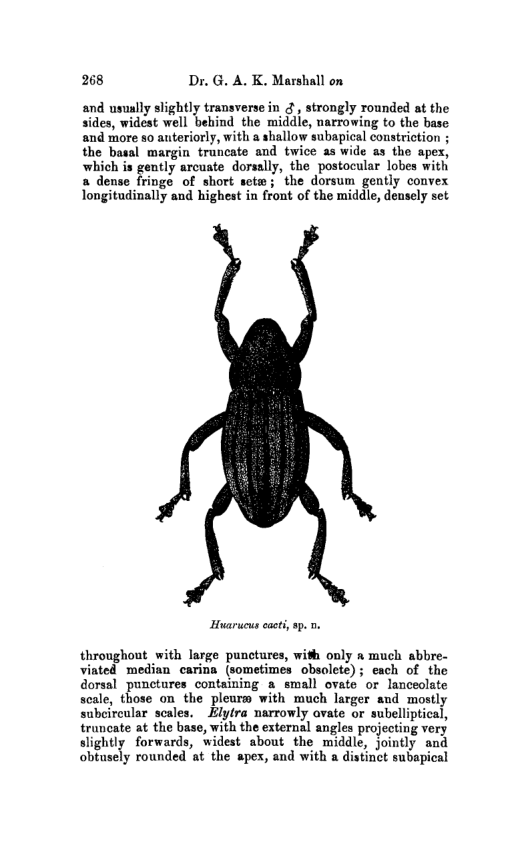

In [48]:
from IPython.display import Image as ShowImage, display
display(ShowImage(data=base64.b64decode(render_page(legacy, 6))))

Now that we know this works, we will define a function that will get the OCR for a given page. This will help us repeat it many times.

In [49]:
def ocr_page(doc, page, dpi=DEFAULT_DPI):
    """Transcribe a page from its image, with region coordinates.

    Coordinates come back scaled 0-1000, labelled text / image /
    image_caption. No think= here: this model does not reason, it transcribes.
    """
    reply = ollama.generate(
        model=OCR_MODEL,
        prompt="<image>\n<|grounding|>Convert the document to markdown.",
        images=[render_page(doc, page, dpi=dpi)],
        options={"temperature": 0, "num_predict": 4096},
    )
    return reply.response or ""

### Cropping the figure

The regions are just coordinates in the text. We have to manually parse them out and cut the
image.

The functions below will open a page and cut figures that deepseek OCR identified. Again, we will not go over the details, feel free to reuse the code!

In [50]:
def regions(ocr_text):
    """Every labelled region: [(label, x1, y1, x2, y2), ...], scaled 0-1000."""
    found = re.findall(r"(\w+)\s*\[\[\s*(\d+),\s*(\d+),\s*(\d+),\s*(\d+)\s*\]\]",
                       ocr_text)
    return [(lab, *map(int, box)) for lab, *box in found]

def crop_region(doc, page, box, dpi=150, pad=0.01):
    """Cut one 0-1000 box out of a rendered page."""
    im = Image.open(io.BytesIO(
        doc[page - 1].get_pixmap(dpi=dpi).tobytes("png")))
    W, H = im.size
    _, x1, y1, x2, y2 = box
    return im.crop((int((x1/1000 - pad) * W), int((y1/1000 - pad) * H),
                    int((x2/1000 + pad) * W), int((y2/1000 + pad) * H)))

for r in regions(reply.response):
    print(r)

('text', 152, 114, 855, 239)
('image', 287, 258, 718, 715)
('image_caption', 395, 725, 610, 743)
('text', 148, 759, 853, 899)


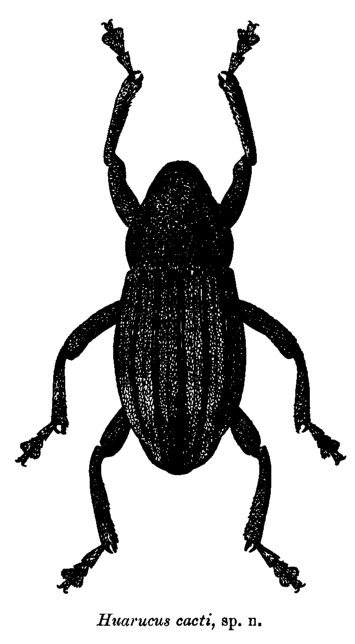

In [51]:
figures = [r for r in regions(reply.response) if r[0] in ("image", "image_caption")]
if figures:
    x1 = min(f[1] for f in figures); y1 = min(f[2] for f in figures)
    x2 = max(f[3] for f in figures); y2 = max(f[4] for f in figures)
    crop = crop_region(legacy, 6, ("figure", x1, y1, x2, y2))
    crop.save("figure_huarucus.png")
    display(crop)

### One function for both kinds of PDF

We have now done the job twice, by hand, in two completely different ways: for
the born-digital paper we asked the PDF for its image objects, and for the scan
we asked the OCR model where the figures were and cut them out ourselves.

Let's wrap both up so we can point them at any page of any PDF. Again, do not
worry about the details — the useful part is the last function, `page_figures()`,
which tries the cheap route first and only calls the OCR model if the page turns
out to have no figure objects in it.

**`figure_boxes()`**: groups each `image` region the OCR model found with the `image_caption` that belongs to it.

**`figures_from_ocr()`**: OCRs a page, then crops out every figure it reported. For scans.

**`figures_from_objects()`**: pulls out the figures a born-digital PDF stores as objects. A scanned page holds exactly one image object — the photograph of the whole page — so we ignore anything covering most of the page, and anything tiny (journal logos, publisher marks).

**`page_figures()`**: objects if there are any, OCR otherwise.

**`show_figures()`**: displays them at a sane size.

In [52]:
MIN_FIGURE_AREA = 0.03   # smaller than this is a logo, not a figure
MAX_FIGURE_AREA = 0.90   # bigger than this is the page scan itself

def figure_boxes(ocr_text):
    """One box per figure, each grown to include its caption. Scaled 0-1000."""
    regs     = regions(ocr_text)
    images   = [r for r in regs if r[0] == "image"]
    captions = [r for r in regs if r[0] == "image_caption"]
    boxes = []
    for img in images:
        group = [img] + [c for c in captions
                         if c[1] < img[3] and c[3] > img[1]   # overlaps it sideways
                         and abs(c[2] - img[4]) < 100]        # and sits just below
        boxes.append(("figure",
                      min(g[1] for g in group), min(g[2] for g in group),
                      max(g[3] for g in group), max(g[4] for g in group)))
    return boxes

def figures_from_ocr(doc, page, dpi=150, pad=0.01):
    """Figures on a scanned page: the OCR model finds them, we cut them out."""
    return [crop_region(doc, page, box, dpi=dpi, pad=pad)
            for box in figure_boxes(ocr_page(doc, page))]

def figures_from_objects(doc, page):
    """Figures a born-digital PDF stores as objects, ready to pull out."""
    pg = doc[page - 1]
    page_area = pg.rect.width * pg.rect.height
    found = []
    for xref, *_ in pg.get_images(full=True):
        placed = pg.get_image_rects(xref)
        share = max((r.width * r.height) / page_area for r in placed) if placed else 0
        if not MIN_FIGURE_AREA <= share <= MAX_FIGURE_AREA:
            continue
        pix = pymupdf.Pixmap(doc, xref)
        if pix.colorspace is None:      # a stencil mask, not a picture
            continue
        found.append(Image.open(io.BytesIO(pix.tobytes("png"))))
    return found

def page_figures(doc, page, dpi=150):
    """Every figure on a page, whichever kind of PDF it came from.

    Cheap route first: if the page has figure objects, we are done. Only if it
    has none do we pay for an OCR call to go looking in the pixels.
    """
    return figures_from_objects(doc, page) or figures_from_ocr(doc, page, dpi=dpi)

def show_figures(figs, width=350):
    """Display figures small enough to fit in a notebook."""
    print(len(figs), "figure(s)")
    for fig in figs:
        small = fig.copy()
        small.thumbnail((width, 4 * width))
        display(small)

Let's check it against the two pages we just did by hand — page 3 of the modern
paper (objects, instant) and page 6 of the scan (OCR, slower):

modern, page 3:
1 figure(s)


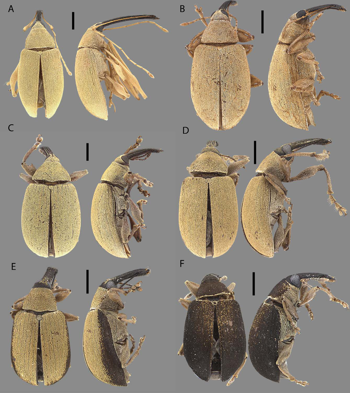

legacy, page 6:
1 figure(s)


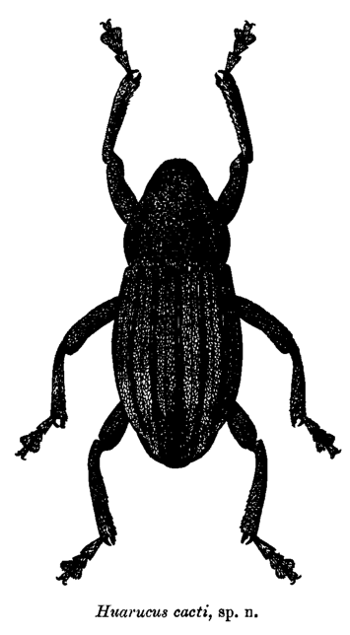

In [53]:
print("modern, page 3:")
show_figures(page_figures(modern, 3))

print("legacy, page 6:")      # no objects here, so this one calls the OCR model
show_figures(page_figures(legacy, 6))

### Your turn — a PDF of your own

Bring in a paper you actually care about and see what comes out of it.

1. Click the **folder icon 📁** in the left sidebar, open the `example_pdfs`
   folder, and drag your PDF into it. Wait for the upload to finish.
2. In the cell below, put your file name in `MY_PDF` and the page you want in
   `MY_PAGE`.
3. Run it. You get the PDF's own text layer, a fresh OCR transcription of the
   same page, and any figures on it.

Things worth looking for:

- Is there a text layer at all? A pure scan may give you nothing.
- Where do the text layer and the fresh OCR disagree? Those disagreements are
  where a silently wrong extraction would come from.
- Did `page_figures()` find your figures? If your paper is born-digital and it
  came back empty, the figure may be *drawn* in the PDF as vector art rather
  than stored as an image object — there is no object to pull out, so treat that
  page like a scan and pass `figures_from_ocr(doc, page)` instead.

In [ ]:
MY_PDF  = "example_pdfs/CHANGE_THIS.pdf"   # your file, uploaded into example_pdfs/
MY_PAGE = 1                                # the page you want to look at

if not os.path.exists(MY_PDF):
    print(f"{MY_PDF} not found. Files currently in example_pdfs/:")
    for f in sorted(glob.glob("example_pdfs/*.pdf")):
        print("   ", f)
else:
    mine = open_pdf(MY_PDF)
    print(f"{MY_PDF}: {mine.page_count} pages\n")

    print("--- the PDF's own text layer ---")
    print(get_page_text(mine, MY_PAGE)[:800] or "(empty — this page is a pure scan)")

    print("\n--- a fresh OCR transcription of the same page ---")
    print(ocr_page(mine, MY_PAGE)[:800])

    print("\n--- figures ---")
    show_figures(page_figures(mine, MY_PAGE))

**Recap.** Born-digital PDFs give you clean text and figures as objects. Scans
give you pixels and, often, a text layer that is wrong without saying so. OCR
recovers the text and tells you where each region sits, which is enough to cut
figures out of a page that contains no figure objects. `page_figures()` picks
between the two for you.

Next: turning this text into data.

---
# Session 3 — Structured extraction

Now we know how to interact with Ollama with 2 kinds of models:

- A multimodal model that can read text and pictures and give us a response.

- A specialized OCR model that reads the image of a page and returns its layout and text.

**What we're doing:**  Now we will take a pdf as input and use an LLM to extract structured data from it.

**Why:** a paragraph is not data. To compare hundreds of morphological descriptions (or pollination papers, or anything you are interested in!), you need
the same fields, with the same names, every time.

We will start by using our OCR model to extract the text from our legacy paper. We will save this text to a file in JSON format, keeping the pagination:

In [55]:
# Long-running: OCR every page of the scanned paper and keep the text.
legacy_ocr = {}
for pno in range(2, legacy.page_count + 1):
    legacy_ocr[pno] = ocr_page(legacy, pno)
    print(f"page {pno} done ({len(legacy_ocr[pno])} chars)")

with open("legacy_ocr.json", "w") as fh:
    json.dump(legacy_ocr, fh, indent=1)
print("saved legacy_ocr.json")

page 2 done (2095 chars)
page 3 done (2759 chars)
page 4 done (2702 chars)
page 5 done (2666 chars)
page 6 done (1061 chars)
page 7 done (2820 chars)
page 8 done (2583 chars)
saved legacy_ocr.json


### How to constrain the output

Let's start by asking the model to constrain the output to a specific format. Because we like JSON, JSON it is. Let's try this on page 2 of our modern pdf. After finished, let's discuss the response. Did you get the same as I did?

In [56]:
reply = ollama.chat(
    model=CHAT_MODEL,
    messages=[{"role": "user",
               "content": "List the species and their traits as JSON.\n\n"
                          + get_page_text(modern, 2)}],
    format="json",
    think=False,
    options={"temperature": 0},
)
print(reply.message.content)

{
  "Anchylorhynchus pinocchio": {
    "status": "sp. n.",
    "holotype": {
      "sex": "Male",
      "location": "Colombia, Casanare, Yopal, Corregimiento Morichal",
      "date": "30/IX/2010",
      "collector": "L. Núñez & J. Carreño",
      "host_plant": "Syagrus sancona",
      "deposited_in": "ICN"
    },
    "paratypes": [
      {
        "location": "Colombia, Casanare, Sabanalarga, Vereda Piñal",
        "date": "20/VII/2010",
        "collector": "L. A. Núñez",
        "count": "5♂ 2♀",
        "deposited_in": "MZSP"
      },
      {
        "location": "Colombia, Casanare, Yopal, Corregimiento Morichal",
        "date": "11/VI/2008",
        "collector": "L. A. Núñez",
        "count": "1♀",
        "deposited_in": "MZSP"
      },
      {
        "location": "Colombia, Casanare, Yopal, Corregimiento Morichal",
        "date": "30/IX/2010",
        "collector": "L. Núñez & J. Carreño",
        "count": "5♂ 5♀",
        "deposited_in": "ICN"
      },
      {
        "locatio

### A schema

A better way to constrain the response is to use a SCHEMA.

A [JSON schema](https://en.wikipedia.org/wiki/JSON#Metadata_and_schema) is a dictionary describing the shape you want. It includes which variables you want, what type they are, etc.

Using ollama, we can pass schemas using
`format=` and the model will constrain its response to the schema. Let's start with a simple schema that extracts the name, author, synonyms and minimum and maximum length of each species.

The schema below only makes species name and author mandatory (it is possible the other data is missing). It tells the type to expect for each field (types can be *string*, *number*, *array* (an unnamed list of things, like a Python list) and *object* (a named list of things, like a Python dictionary)).

We use `"additionalProperties": False` to prevent the model from adding additional traits.

In [57]:
SPECIES_SCHEMA = {
    "type": "object",
    "properties": {
        "name": {"type": "string"},
        "author": {"type": "string"},
        "min_length": {"type": "number"},
        "max_length": {"type": "number"},
        "synonyms": {
            "type": "array",
            "items": {"type": "string"}
        }
    },
    "required": ["name", "author"],
    "additionalProperties": False
}

Let's now try our prompt again but with this schema. For that, we just replace `format=json` with `format=SPECIES_SCHEMA`, the variable where we saved our schema.

In [58]:
reply = ollama.chat(
    model=CHAT_MODEL,
    messages=[{"role": "user",
               "content": "List the species and their traits as JSON. min_length and max_length are the minimum and maximum lengths mentioned for each species\n\n"
                          + get_page_text(modern, 2)}],
    format=SPECIES_SCHEMA,
    think=False,
    options={"temperature": 0},
)
print(reply.message.content)

{
  "name": "Anchylorhynchus pinocchio",
  "author": "sp. n.",
  "min_length": 4.5,
  "max_length": 5.7,
  "synonyms": []
}


We can now use the python library `json` to load this json-formatted object as a python object including strings, numbers, lists and dictionaries:

In [61]:
json_result = json.loads(reply.message.content)
json_result

{'name': 'Anchylorhynchus pinocchio',
 'author': 'sp. n.',
 'min_length': 4.5,
 'max_length': 5.7,
 'synonyms': []}

And we can easily transform JSON into tables using Python:

In [63]:
pd.DataFrame([json_result])

,name,author,min_length,max_length,synonyms
0,Anchylorhynchus pinocchio,sp. n.,4.5,5.7,[]


### The whole paper, figures included

Now that we have done this for one page, let's do a whole paper. A real extraction takes the whole document, and
a taxonomic paper keeps a lot of its data in the plates — so we send the figures
too. `qwen3.5:9b` is multimodal, which means a message can carry images
alongside its text.

We need to change two things:

**A whole paper has many species, so the schema has to say so.** `SPECIES_SCHEMA`
describes *one* species. Now we need a larger schema that includes `SPECIES_SCHEMA` explicitly saying there will be many species.

**The model's context window is not automatically big enough.** A page of text
is a few hundred tokens; a whole paper plus its figures is tens of thousands.
Ollama gives you a modest default context, and anything past it is *dropped
without an error* — you get a confident answer based on the half of the paper
the model actually saw. `num_ctx` is how you ask for room. We need to set a larger context. For very large papers, you may need a bigger model, more GPU memory, or both.

This cell reads all seven pages and three figures, so it takes a couple of
minutes.

In [64]:
PAPER_SCHEMA = {
    "type": "object",
    "properties": {
        "species": {"type": "array", "items": SPECIES_SCHEMA}
    },
    "required": ["species"],
    "additionalProperties": False,
}

def pdf_text(doc, pages=None):
    """The whole text layer, page by page, with the page numbers left in."""
    pages = pages or range(1, doc.page_count + 1)
    return "\n\n".join(f"--- page {p} ---\n{get_page_text(doc, p)}" for p in pages)

def pdf_figures(doc, pages=None, use_ocr=False):
    """Every figure in a document.

    use_ocr=False only looks for figure objects, which is instant. Set it to
    True for a scan, where finding a figure costs one OCR call per page.
    """
    pages = pages or range(1, doc.page_count + 1)
    finder = page_figures if use_ocr else figures_from_objects
    return [fig for p in pages for fig in finder(doc, p)]

def as_image_data(fig, max_side=1024):
    """A figure, shrunk if it is huge, encoded the way a model wants it."""
    small = fig.copy()
    small.thumbnail((max_side, max_side))
    buf = io.BytesIO()
    small.save(buf, format="PNG")
    return base64.b64encode(buf.getvalue()).decode()

WHOLE_PAPER_PROMPT = (
    "List every species this paper describes, using both the text and the "
    "figures. name is the species name. author is the taxonomic authority for "
    "that name -- the person who described it -- not an author of this paper; "
    "for a species described as new here, use the paper's own authors. "
    "min_length and max_length are the smallest and largest body length in mm "
    "given for the species. Do not invent values that are not stated.\n\n"
)

figures = pdf_figures(modern)
text = pdf_text(modern)
print(f"sending {len(text)} characters of text and {len(figures)} figures")

reply = ollama.chat(
    model=CHAT_MODEL,
    messages=[{"role": "user",
               "content": WHOLE_PAPER_PROMPT + text,
               "images": [as_image_data(f) for f in figures]}],
    format=PAPER_SCHEMA,
    think=False,
    options={"temperature": 0, "num_ctx": 16384},
)

species = json.loads(reply.message.content)["species"]
print(f"{len(species)} species\n")
pd.DataFrame(species)

sending 21304 characters of text and 3 figures
3 species



,name,author,min_length,max_length
0,Anchylorhynchus pinocchio,De Medeiros & Núñez-Avellaneda,4.5,5.7
1,Anchylorhynchus centrosquamatus,De Medeiros & Núñez-Avellaneda,4.7,5.9
2,Anchylorhynchus luteobrunneus,De Medeiros & Núñez-Avellaneda,3.9,4.8


Read that table against the paper. Because we used a schema, the shape is guaranteed - it will only have what we asked for. But there may be content errors.  Worth checking before you trust any of it:

- Did it find every species, and only species that are really described here?
- Are the lengths the ones in the text, or ones it assembled from nearby
  numbers? A ratio, a scale bar and a body length all look alike to a model.
- Is `author` a taxonomic authority, or did it fall back on "sp. n."? Compare
  with what came back before we spelled the field out in the prompt.

### Two functions to carry forward

Every extraction we have run has the same shape: text (and maybe figures) in, a
schema and a prompt to say what we want back, JSON out, a table to look at.
Let's name it once, because from here on — the exercise below, and all of
Session 5 — we call these two instead of writing the call out again.

**`extract()`**: takes the text, the schema and the prompt, and hands back the
parsed JSON. `figures=` adds images to the message. `client=` sends the request
to a different server, which is the only change Session 5 needs to run all of
this on a much bigger model.

**`to_table()`**: pulls the array of records out of the result and makes a
DataFrame of it. The array's name is part of *your* schema, so it is an
argument — `"species"` for `PAPER_SCHEMA`, something else for yours.

Together they turn the cell above into one line:
`to_table(extract(pdf_text(modern), figures=pdf_figures(modern)))`

In [ ]:
def extract(text, schema=PAPER_SCHEMA, prompt=WHOLE_PAPER_PROMPT, figures=None,
            model=CHAT_MODEL, client=None, num_ctx=16384):
    """Text (and figures) in, structured data out.

    client is None for the server on this machine. Session 5 passes a client
    pointed at Ollama's servers instead, which is the only change needed to
    run any of this on a far bigger model.
    """
    message = {"role": "user", "content": prompt + text}
    if figures:
        message["images"] = [as_image_data(fig) for fig in figures]

    chat = (client or ollama).chat
    reply = chat(
        model=model,
        messages=[message],
        format=schema,
        think=False,
        options={"temperature": 0, "num_ctx": num_ctx},
    )
    return json.loads(reply.message.content)

def to_table(data, key="species"):
    """The array of records inside an extraction result, as a table.

    Our schemas wrap the records in one named array -- "species" in
    PAPER_SCHEMA. Pass key= if you named yours something else.
    """
    return pd.DataFrame(data.get(key, []))

# Try it yourself

Now let's practice. Use the placeholders below to set the schema for each species, the global schema, and the prompt with the details of what you want. Try to extract some information of your choice from the historical pdf.

In [ ]:
# ---------------------------------------------------------------- 1. one record
# The fields you want for each thing you are extracting -- the equivalent of
# SPECIES_SCHEMA above. Rename the placeholders and set each type to "string"
# or "number".
MY_ITEM_SCHEMA = {
    "type": "object",
    "properties": {
        "FIELD_ONE":   {"type": "string"},
        "FIELD_TWO":   {"type": "string"},
        "FIELD_THREE": {"type": "number"},
    },
    "required": ["FIELD_ONE"],       # only the fields that must always be there
    "additionalProperties": False,
}

# ------------------------------------------------------------ 2. the whole answer
# A paper holds many of them, so wrap the record schema in an array -- the
# equivalent of PAPER_SCHEMA above. Rename "records" if you like, and pass the
# same name to to_table() at the bottom.
MY_SCHEMA = {
    "type": "object",
    "properties": {
        "records": {"type": "array", "items": MY_ITEM_SCHEMA}
    },
    "required": ["records"],
    "additionalProperties": False,
}

# ------------------------------------------------------------------ 3. the prompt
# Say what to extract, and say what every field means. Leaving a field
# unexplained is how we got "sp. n." in the author column earlier.
MY_PROMPT = (
    "DESCRIBE WHAT TO EXTRACT HERE. "
    "FIELD_ONE is ... FIELD_TWO is ... FIELD_THREE is ... "
    "Do not invent values that are not stated in the text.\n\n"
)

# ------------------------------------------------- 4. run it on the 1929 paper
# The OCR text from the long-running cell at the start of this session -- not
# the PDF's own text layer, which we know is corrupt.
if "legacy_ocr" not in globals():          # e.g. after a runtime restart
    legacy_ocr = {int(p): t for p, t in json.load(open("legacy_ocr.json")).items()}

legacy_text = "\n\n".join(f"--- page {p} ---\n{legacy_ocr[p]}"
                          for p in sorted(legacy_ocr))
print(f"sending {len(legacy_text)} characters of OCR text")

result = extract(legacy_text, schema=MY_SCHEMA, prompt=MY_PROMPT)
# to send the plate as well:
#     result = extract(legacy_text, schema=MY_SCHEMA, prompt=MY_PROMPT,
#                      figures=pdf_figures(legacy, pages=[6], use_ocr=True))

to_table(result, key="records")

**Recap.** Asking for JSON gets you JSON with unpredictable field names. A
schema passed as `format=` fixes the fields, the types and what is required,
and the model cannot deviate. It cannot tell you whether an answer is *true* —
that check is yours to write.

Next: letting the model decide how to read a page.

---
# Session 4 — An agent that chooses

**What we're doing:** giving the model two tools — cheap text, expensive OCR —
and letting it pick.

**Why:** you will not always know which pages of which document need OCR. The
alternative to deciding yourself is describing the tools well enough that the
model decides.

Tools are described as JSON, much like the schema. The description is what the
model reads to choose — write it for the model, not for yourself.

In [ ]:
TOOLS = [
    {"type": "function",
     "function": {
         "name": "get_page_text",
         "description": ("Return the PDF's embedded text layer for a page. "
                         "Free and instant, but on scanned documents it can be "
                         "poor-quality OCR with garbled words."),
         "parameters": {"type": "object",
                        "properties": {"page": {"type": "integer",
                                                "description": "1-based page number"}},
                        "required": ["page"]}}},
    {"type": "function",
     "function": {
         "name": "ocr_page",
         "description": ("Re-read a page from its image with a dedicated OCR "
                         "model. Slower, far more accurate on scans."),
         "parameters": {"type": "object",
                        "properties": {"page": {"type": "integer",
                                                "description": "1-based page number"}},
                        "required": ["page"]}}},
]

The model can only *ask* for a tool; we run it and hand back the result. That
back-and-forth is the loop below. It is a function because we call it several
times with different settings.

In [ ]:
def run_tool_loop(messages, tools, impls, think=True, max_turns=6):
    """Let the model call tools until it has an answer.

    Returns (answer, calls_it_made).
    """
    messages = list(messages)
    calls = []
    for _ in range(max_turns):
        reply = ollama.chat(model=CHAT_MODEL, messages=messages, tools=tools,
                            think=think, options={"temperature": 0})
        msg = reply.message
        messages.append({"role": "assistant", "content": msg.content or "",
                         "tool_calls": msg.tool_calls or []})
        if not msg.tool_calls:
            return (msg.content or ""), calls
        for call in msg.tool_calls:
            name = call.function.name
            args = dict(call.function.arguments)
            calls.append((name, args))
            try:
                result = impls[name](**args)
            except Exception as exc:
                result = f"ERROR: {exc}"        # tell the model, don't crash
            messages.append({"role": "tool", "name": name,
                             "content": str(result)[:6000]})
    return f"stopped after {max_turns} turns", calls

impls = {"get_page_text": lambda page: get_page_text(legacy, page),
         "ocr_page":      lambda page: ocr_page(legacy, page)}

SYSTEM = ("You read scanned historical literature. The embedded text layer of "
          "a scan is often corrupt: watch for garbled words and impossible "
          "spellings of taxonomic names. If the text looks corrupt, re-read "
          "the page with ocr_page before trusting it.")
QUESTION = [{"role": "system", "content": SYSTEM},
            {"role": "user", "content":
             "On page 5, what is the family name printed in the running "
             "header at the top? Report it exactly."}]

In [ ]:
answer, calls = run_tool_loop(QUESTION, TOOLS, impls, think=False)
print("tools used:", calls)
print(answer)

It read the corrupt text, noticed something was off, decided it was close
enough, and answered anyway — often inventing a spelling that is in neither the
text nor the page.

Now change one argument.

In [ ]:
answer, calls = run_tool_loop(QUESTION, TOOLS, impls, think=True)
print("tools used:", calls)
print(answer)

With reasoning on it re-reads the page and gets it right. Judging whether your
input is trustworthy *is* reasoning work — it is the same setting that wasted
its time back in Session 1, applied to a task that actually needs it.

### Why not just write a rule?

Tempting: scan the text for odd characters and call OCR when you find them.
It works on the page you tuned it on. There is no finite list of ways OCR can
be wrong, so it fails on the next document — silently, which is the worst way.

In practice you either already know which of your PDFs are scans, or you ask a
model that can reason.

### Hands-on 2

Run the loop over several pages and watch which ones it sends to OCR.

In [ ]:
for pno in [2, 5, 6]:
    q = [{"role": "system", "content": SYSTEM},
         {"role": "user", "content":
          f"What is printed at the very top of page {pno}? Report it exactly."}]
    answer, calls = run_tool_loop(q, TOOLS, impls, think=True)
    print(f"p{pno}: {[c[0] for c in calls]} -> {' '.join(answer.split())[:90]}")

**Recap.** You described two tools, ran the loop that lets a model use them,
and saw that the same code fails or succeeds depending on whether reasoning is
switched on. Deciding *where* a decision lives — in your code or in the model —
is the judgement that carries over to your own pipelines.

Next: doing this at scale.

---
# Session 5 — Scaling up

**What we're doing:** swapping in a much larger model, then running the whole
pipeline over every PDF in a folder.

**Why:** the shape of the code is the same for two documents or four thousand.
What changes is that you save results as you go, so a failure halfway through
does not cost you the whole run.

### Get your own API key

The models we have used so far fit on this machine. Bigger ones do not, but
Ollama runs them on their servers and the code barely changes.

You need a key of your own. It is free and takes two minutes:

1. Go to **[ollama.com](https://ollama.com)** and create an account. No card
   required.
2. Go to **[ollama.com/settings/keys](https://ollama.com/settings/keys)** →
   **Create key**. Copy it. You will not be shown it again.
3. Back in Colab, click the **🔑 key icon** in the left sidebar.
4. **+ Add new secret**. Name it exactly `OLLAMA_API_KEY`, paste your key into
   the value box, and turn on **Notebook access**.

**Never paste a key into a cell.** Anything typed into a notebook gets shared
when the notebook does — with your collaborators, in your repository, in the
copy you email to a student. Colab Secrets keeps it out of the file.

In [ ]:
from ollama import Client

def cloud_client():
    """A client pointed at Ollama's servers instead of this machine.

    Same interface as the local one, so everything we have written already
    works against it -- we only have to say where to send the request and
    who is asking.
    """
    try:
        from google.colab import userdata
        key = userdata.get("OLLAMA_API_KEY")
    except Exception:
        key = os.environ.get("OLLAMA_API_KEY")
    if not key:
        raise RuntimeError(
            "No key found. Add OLLAMA_API_KEY to Colab Secrets (key icon, "
            "left sidebar) and switch on Notebook access for this notebook.")
    return Client(host="https://ollama.com",
                  headers={"Authorization": "Bearer " + key})

# Browse what is available at https://ollama.com/search?c=cloud
# Note: no "-cloud" suffix when talking to the servers directly.
CLOUD_MODEL = "gpt-oss:120b"

try:
    cloud = cloud_client()
    data = extract(get_page_text(modern, 2)[:4000],
                   model=CLOUD_MODEL, client=cloud)
    display(to_table(data).head())
except Exception as exc:
    print("Cloud step skipped:", exc)

That is the whole difference: same prompt, same schema, same `extract`
function — a different client and a model roughly a hundred times larger.

The free tier is metered, so keep cloud calls small. Everything else today
runs on the machine in front of you.

### Every PDF in a folder

One JSON file per document, written as we go.

In [ ]:
def process_pdf(path, model=CHAT_MODEL, max_chars=12000):
    """Read a PDF, extract structured data, return it."""
    doc = open_pdf(path)
    text = "\n".join(get_page_text(doc, p)
                     for p in range(1, doc.page_count + 1))
    return extract(text[:max_chars], model=model)

os.makedirs("results", exist_ok=True)

for path in sorted(glob.glob("example_pdfs/*.pdf")):
    name = os.path.splitext(os.path.basename(path))[0]
    out_path = f"results/{name}.json"
    if os.path.exists(out_path):
        print("skip (already done):", name)
        continue
    try:
        data = process_pdf(path)
        with open(out_path, "w") as fh:
            json.dump(data, fh, indent=1)
        n = sum(len(s.get("traits", [])) for s in data.get("species", []))
        print(f"{name}: {len(data.get('species', []))} species, {n} traits")
    except Exception as exc:
        print(f"{name}: FAILED -- {exc}")

Skipping files that already have output means you can re-run the cell after a
crash and it picks up where it stopped. At any real scale this matters more
than anything else in the loop.

### One table

In [ ]:
frames = []
for path in sorted(glob.glob("results/*.json")):
    with open(path) as fh:
        data = json.load(fh)
    t = to_table(data)
    t.insert(0, "source", os.path.basename(path).replace(".json", ""))
    frames.append(t)

combined = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
print(combined.shape)
combined.to_csv("results/combined.csv", index=False)
combined.head(15)

### Hands-on 3 — your own data

Upload a few of your own PDFs, write a schema for what *you* want out of them,
and run the same loop.

1. Click the folder icon 📁 in the left sidebar and upload PDFs into
   `my_pdfs/` (create it in the cell below).
2. Edit `MY_SCHEMA` for the fields you want.
3. Edit `MY_PROMPT` to say what to extract.
4. Run.

Start with two or three pages of one document while you are getting the prompt
right — not your whole library.

In [ ]:
os.makedirs("my_pdfs", exist_ok=True)
print("Upload PDFs into my_pdfs/ using the folder icon in the sidebar.")

MY_SCHEMA = {
    "type": "object",
    "properties": {
        "records": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "FIELD_ONE":   {"type": "string"},
                    "FIELD_TWO":   {"type": "string"},
                    "source_text": {"type": "string"},
                },
                "required": ["FIELD_ONE", "source_text"],
            },
        }
    },
    "required": ["records"],
}

MY_PROMPT = (
    "DESCRIBE WHAT TO EXTRACT HERE. Be specific. Copy the exact sentence "
    "each value came from into source_text.\n\n"
)

def my_extract(text, model=CHAT_MODEL):
    reply = ollama.chat(
        model=model,
        messages=[{"role": "user", "content": MY_PROMPT + text}],
        format=MY_SCHEMA,
        think=False,
        options={"temperature": 0},
    )
    return json.loads(reply.message.content)

for path in sorted(glob.glob("my_pdfs/*.pdf")):
    doc = open_pdf(path)
    text = "\n".join(get_page_text(doc, p)
                      for p in range(1, min(doc.page_count, 3) + 1))
    try:
        result = my_extract(text[:8000])
        print(os.path.basename(path))
        display(pd.DataFrame(result.get("records", [])))
    except Exception as exc:
        print(f"{os.path.basename(path)}: {exc}")

**Recap.** The pipeline is a loop: read a document, extract with a schema, save
the result, move on. Saving per document and skipping finished work is what
makes it survivable at scale. Swapping to a larger model is a one-line change.

**Where to go from here**

- Test on a handful of documents you have already scored by hand, and measure
  how often the model agrees with you, before trusting a large run.
- Keep `source_text`. An extraction you cannot trace is not evidence.
- Pin your model *and* your Ollama version if you publish a method — open
  weights can be archived alongside your data, and a hosted model cannot.